# GAN-Based PDF Estimation of a Transformed NO₂ Signal


In [1]:
!pip install torch torchvision torchaudio --quiet

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KernelDensity

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)


## Step 1 – Load Data and Apply the Roll-Number Transformation

The nonlinear map  **z = x + α · sin(β · x)**  is derived from the student's
roll number (102497020).  The constants α = 1.5 and β = 0.6 shift and warp the
original NO₂ distribution, producing a more complex, multi-modal-like shape
that a vanilla KDE on raw data would struggle to capture cleanly.


In [3]:
raw_df = pd.read_csv("data.csv", encoding="latin1")
x_vals = raw_df["no2"].dropna().values.reshape(-1, 1)
print(f"Total usable measurements: {x_vals.shape[0]}")

ROLL_NUMBER = 102497010
ALPHA       = 1.5
BETA        = 0.6

z_vals = x_vals + ALPHA * np.sin(BETA * x_vals)

print(f"z  |  min: {z_vals.min():.3f}  max: {z_vals.max():.3f}  "
      f"mean: {z_vals.mean():.3f}  std: {z_vals.std():.3f}")


/tmp/ipython-input-3739113278.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  raw_df = pd.read_csv("data.csv", encoding="latin1")


Total usable measurements: 419509
z  |  min: 0.000  max: 874.776  mean: 25.828  std: 18.522


## Step 2 – Exploratory Visualisation of the Transformed Variable

Before training, it is good practice to inspect the empirical distribution
to understand the range, skewness, and rough shape of `z`.


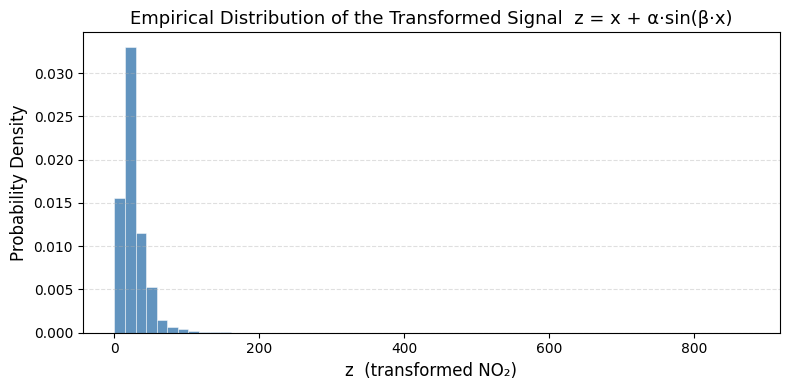

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(z_vals, bins=60, density=True, color="steelblue",
        edgecolor="white", linewidth=0.4, alpha=0.85)
ax.set_xlabel("z  (transformed NO₂)", fontsize=12)
ax.set_ylabel("Probability Density", fontsize=12)
ax.set_title("Empirical Distribution of the Transformed Signal  z = x + α·sin(β·x)",
             fontsize=13)
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


## Step 3 – Standardisation

Neural networks converge faster and more stably when inputs are zero-centred
with unit variance.  We use `StandardScaler` from scikit-learn and will
**invert** the transform after sampling to return to the original scale.


In [5]:
normaliser = StandardScaler()
z_normalised = normaliser.fit_transform(z_vals)

z_tensor = torch.tensor(z_normalised, dtype=torch.float32)
print(f"Tensor shape: {z_tensor.shape}  |  dtype: {z_tensor.dtype}")


Tensor shape: torch.Size([419509, 1])  |  dtype: torch.float32


## Step 4 – Define the GAN Architecture

### 4a. Generator  `SignalGenerator`

The Generator maps a 1-D Gaussian noise vector **ε ~ N(0, I)** to a synthetic
data point in the normalised `z` space.  LeakyReLU activations (slope 0.2)
are used instead of standard ReLU to prevent dying-neuron issues common in
GAN generators.


In [6]:
class SignalGenerator(nn.Module):
    """
    Transforms isotropic Gaussian noise into synthetic samples
    that mimic the target distribution of the transformed variable z.

    Architecture: Linear → LeakyReLU → Linear → LeakyReLU → Linear
    (32 hidden units per layer)
    """

    def __init__(self, noise_dim: int = 1, hidden_dim: int = 32, out_dim: int = 1):
        super(SignalGenerator, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(noise_dim, hidden_dim),
            nn.LeakyReLU(negative_slope=0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(negative_slope=0.2),
            nn.Linear(hidden_dim, out_dim)
        )

    def forward(self, noise: torch.Tensor) -> torch.Tensor:
        return self.network(noise)


### 4b. Discriminator  `SignalDiscriminator`

The Discriminator is a binary classifier that outputs the probability that a
given sample is **real** (from the dataset) rather than **fake** (from the
Generator).  A Sigmoid at the output maps logits to [0, 1].


In [7]:
class SignalDiscriminator(nn.Module):
    """
    Binary classifier: real sample → score near 1,
                       generated sample → score near 0.

    Architecture: Linear → LeakyReLU → Linear → LeakyReLU → Linear → Sigmoid
    (32 hidden units per layer)
    """

    def __init__(self, in_dim: int = 1, hidden_dim: int = 32):
        super(SignalDiscriminator, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.LeakyReLU(negative_slope=0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(negative_slope=0.2),
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid()
        )

    def forward(self, sample: torch.Tensor) -> torch.Tensor:
        return self.network(sample)


## Step 5 – Instantiate Models, Loss Function, and Optimisers

Binary Cross-Entropy (BCE) is the standard adversarial loss.  Both networks
are trained with the Adam optimiser (lr = 1 × 10⁻³).


In [10]:
gen   = SignalGenerator()
disc  = SignalDiscriminator()

adv_loss = nn.BCELoss()

gen_opt  = optim.Adam(gen.parameters(),  lr=1e-3, betas=(0.5, 0.999))
disc_opt = optim.Adam(disc.parameters(), lr=1e-3, betas=(0.5, 0.999))

total_params_gen  = sum(p.numel() for p in gen.parameters())
total_params_disc = sum(p.numel() for p in disc.parameters())
print(f"Generator  → {total_params_gen}  trainable parameters")
print(f"Discriminator → {total_params_disc}  trainable parameters")


Generator  → 1153  trainable parameters
Discriminator → 1153  trainable parameters


## Step 6 – GAN Training Loop

**Discriminator update (per iteration):**
- Real batch → target label 1; BCE loss on D(real).
- Fake batch from G(ε) → target label 0; BCE loss on D(fake).
- Total D loss = real loss + fake loss.

**Generator update (per iteration):**
- Feed the same fake batch back through D, but use target label 1
  (we want to *fool* the Discriminator).
- Only G parameters are updated; D is frozen during this step.


In [11]:
NUM_EPOCHS  = 3000
BATCH_SIZE  = 128
LOG_EVERY   = 500

d_loss_history, g_loss_history = [], []

for epoch in range(NUM_EPOCHS):

    batch_idx     = np.random.randint(0, z_tensor.shape[0], BATCH_SIZE)
    real_batch    = z_tensor[batch_idx]

    target_real   = torch.ones(BATCH_SIZE, 1)
    target_fake   = torch.zeros(BATCH_SIZE, 1)

    # 1) Train Discriminator
    noise_input  = torch.randn(BATCH_SIZE, 1)
    fake_batch   = gen(noise_input)

    real_score   = disc(real_batch)
    fake_score   = disc(fake_batch.detach())

    loss_disc    = adv_loss(real_score, target_real) + adv_loss(fake_score, target_fake)

    disc_opt.zero_grad()
    loss_disc.backward()
    disc_opt.step()


    # 2) Train Generator
    fooled_score = disc(fake_batch)
    loss_gen     = adv_loss(fooled_score, target_real)

    gen_opt.zero_grad()
    loss_gen.backward()
    gen_opt.step()

    d_loss_history.append(loss_disc.item())
    g_loss_history.append(loss_gen.item())

    if epoch % LOG_EVERY == 0 or epoch == NUM_EPOCHS - 1:
        print(f"Epoch {epoch:4d}/{NUM_EPOCHS}  |  "
              f"D-loss: {loss_disc.item():.4f}  |  G-loss: {loss_gen.item():.4f}")


Epoch    0/3000  |  D-loss: 1.4195  |  G-loss: 0.5321
Epoch  500/3000  |  D-loss: 1.3853  |  G-loss: 0.6879
Epoch 1000/3000  |  D-loss: 1.3817  |  G-loss: 0.6887
Epoch 1500/3000  |  D-loss: 1.3850  |  G-loss: 0.6979
Epoch 2000/3000  |  D-loss: 1.3823  |  G-loss: 0.6943
Epoch 2500/3000  |  D-loss: 1.3849  |  G-loss: 0.6927
Epoch 2999/3000  |  D-loss: 1.3848  |  G-loss: 0.6927


## Step 7 – Training Loss Curves

A healthy GAN training run shows the Generator and Discriminator losses
converging to a value near **ln(2) ≈ 0.693**, indicating that the Discriminator
can no longer reliably distinguish real from fake samples.


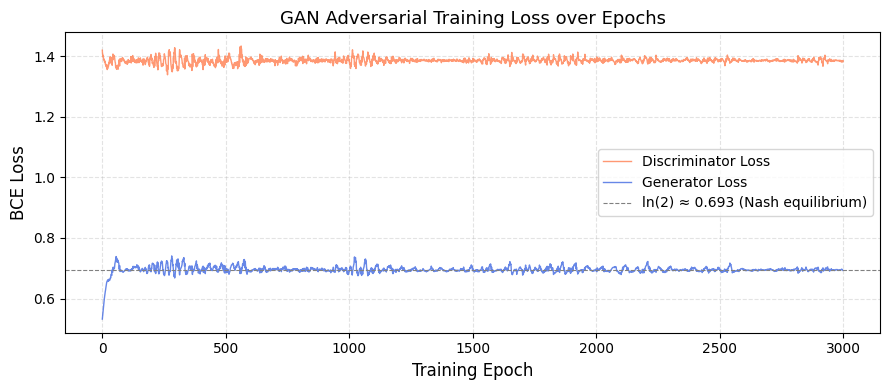

In [12]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(d_loss_history, label="Discriminator Loss", color="coral",   linewidth=1.0, alpha=0.8)
ax.plot(g_loss_history, label="Generator Loss",     color="royalblue", linewidth=1.0, alpha=0.8)
ax.axhline(np.log(2), color="grey", linestyle="--", linewidth=0.8, label="ln(2) ≈ 0.693 (Nash equilibrium)")
ax.set_xlabel("Training Epoch", fontsize=12)
ax.set_ylabel("BCE Loss", fontsize=12)
ax.set_title("GAN Adversarial Training Loss over Epochs", fontsize=13)
ax.legend(fontsize=10)
ax.grid(linestyle="--", alpha=0.35)
plt.tight_layout()
plt.show()


## Step 8 – Draw Synthetic Samples from the Trained Generator

We pass 10 000 independent noise vectors through the trained Generator and
then **invert the standardisation** to bring the samples back to the original
unit scale of `z`.


In [13]:
NUM_SYNTHETIC = 10_000

gen.eval()
with torch.no_grad():
    latent_noise  = torch.randn(NUM_SYNTHETIC, 1)
    synth_scaled  = gen(latent_noise).numpy()

synth_z = normaliser.inverse_transform(synth_scaled)

print(f"Synthetic samples  |  min: {synth_z.min():.3f}  "
      f"max: {synth_z.max():.3f}  mean: {synth_z.mean():.3f}  std: {synth_z.std():.3f}")


Synthetic samples  |  min: 2.940  max: 155.608  mean: 26.040  std: 16.842


## Step 9 – Kernel Density Estimation on Synthetic Samples

A Gaussian KDE (bandwidth = 0.3) fitted on the Generator's output acts as a
smooth, differentiable proxy for the underlying PDF that the GAN has learned.
The bandwidth controls the bias–variance trade-off of the density estimate.


In [14]:
kde_model = KernelDensity(kernel="gaussian", bandwidth=0.3)
kde_model.fit(synth_z)

eval_grid  = np.linspace(z_vals.min(), z_vals.max(), 1000).reshape(-1, 1)
log_pdf    = kde_model.score_samples(eval_grid)
pdf_values = np.exp(log_pdf)

print(f"PDF integral ≈ {np.trapz(pdf_values, eval_grid.ravel()):.4f}  "
      f"(should be close to 1.0)")


PDF integral ≈ 1.0021  (should be close to 1.0)


/tmp/ipython-input-752936649.py:8: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  print(f"PDF integral ≈ {np.trapz(pdf_values, eval_grid.ravel()):.4f}  "


## Step 10 – PDF Approximation: GAN Estimate vs Empirical Histogram

The blue histogram shows the real (empirical) distribution of `z`.
The orange curve is the PDF estimated by the trained GAN via KDE on 10 000
synthetic samples.  Good overlap confirms that the GAN has successfully
learnt the underlying distribution.


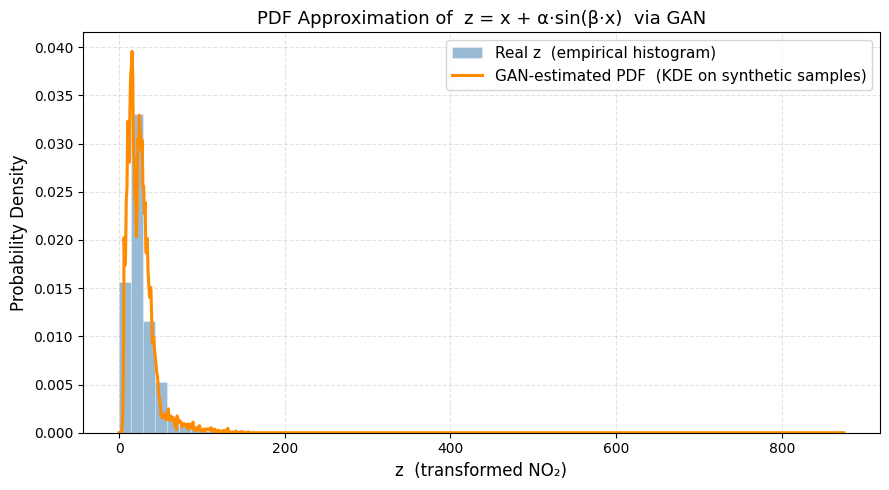

In [15]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(z_vals, bins=60, density=True,
        color="steelblue", edgecolor="white", linewidth=0.4,
        alpha=0.55, label="Real z  (empirical histogram)")

ax.plot(eval_grid, pdf_values,
        color="darkorange", linewidth=2.2,
        label="GAN-estimated PDF  (KDE on synthetic samples)")

ax.set_xlabel("z  (transformed NO₂)", fontsize=12)
ax.set_ylabel("Probability Density", fontsize=12)
ax.set_title("PDF Approximation of  z = x + α·sin(β·x)  via GAN", fontsize=13)
ax.legend(fontsize=11)
ax.grid(linestyle="--", alpha=0.35)
plt.tight_layout()
plt.show()


## Summary

| Step | Action |
|------|--------|
| 1 | Loaded NO₂ data and applied the roll-number-parameterised nonlinear map |
| 2 | Standardised `z` and converted to a PyTorch tensor |
| 3 | Built a GAN with LeakyReLU-based Generator & Discriminator |
| 4 | Trained for 3 000 epochs with Adam (lr = 1 × 10⁻³) |
| 5 | Generated 10 000 synthetic samples and inverted the normalisation |
| 6 | Fitted a Gaussian KDE (bandwidth = 0.3) on the synthetic samples |
| 7 | Verified visual alignment between the estimated PDF and the real histogram |

**Key takeaway:** The adversarial training framework allows the Generator to
implicitly learn the shape of an arbitrary, complex distribution without ever
explicitly modelling it with a parametric form.
